# Order Priority Analysis

## Objective

Analyze the performance of each order priority level based on:
- Total Sales
- Total Profit
 Revenue Contribution

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datas/cleaned_ecommerce.csv")

In [3]:
priority_analysis = (
    df.groupby("Order Priority")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order ID", "nunique")
      )
      .sort_values(by="Total_Sales", ascending=False)
)

priority_analysis

,Total_Sales,Total_Profit,Total_Orders
Order Priority,,,
Medium,4718747.0,2212750.8,29433
High,2348534.0,1081889.7,15499
Critical,544404.0,239239.6,3932
Low,411004.0,195904.5,2424


In [4]:
highest_sales_priority = priority_analysis["Total_Sales"].idxmax()
highest_profit_priority = priority_analysis["Total_Profit"].idxmax()

print(f"Highest Revenue Priority : {highest_sales_priority}")
print(f"Highest Profit Priority  : {highest_profit_priority}")

Highest Revenue Priority : Medium
Highest Profit Priority  : Medium


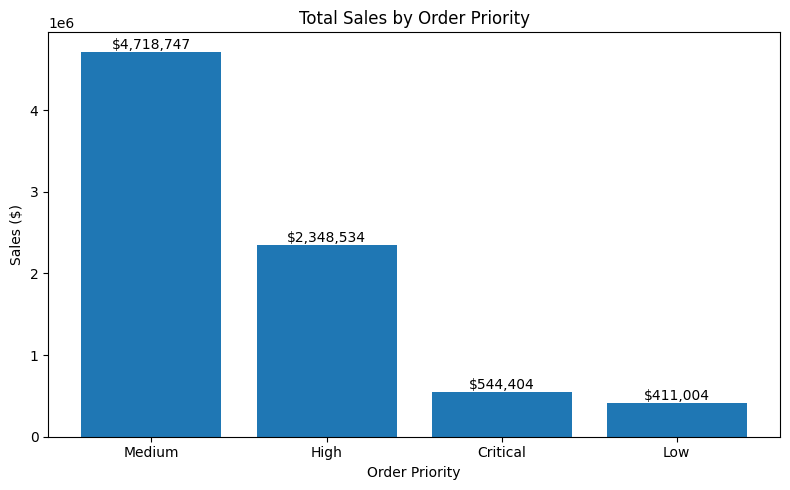

In [5]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    priority_analysis.index,
    priority_analysis["Total_Sales"]
)

plt.title("Total Sales by Order Priority")
plt.xlabel("Order Priority")
plt.ylabel("Sales ($)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../charts/order_priority_sales.png", dpi=300)

plt.show()

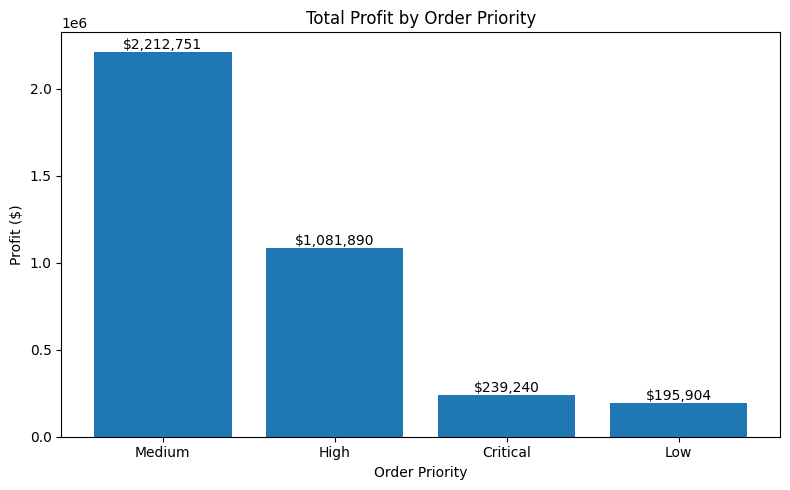

In [6]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    priority_analysis.index,
    priority_analysis["Total_Profit"]
)

plt.title("Total Profit by Order Priority")
plt.xlabel("Order Priority")
plt.ylabel("Profit ($)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../charts/order_priority_profit.png", dpi=300)

plt.show()

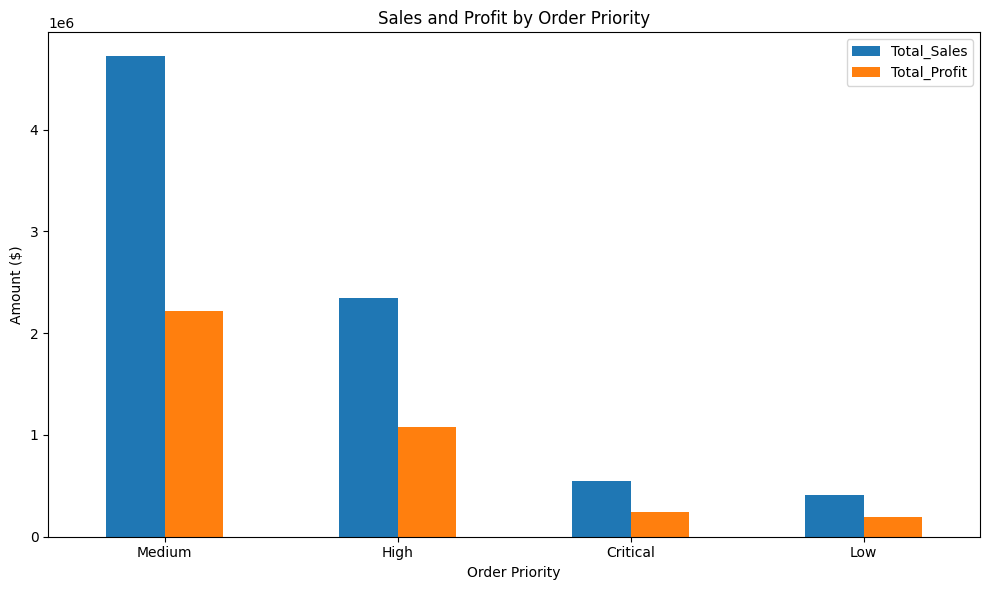

In [7]:
priority_analysis[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sales and Profit by Order Priority")
plt.xlabel("Order Priority")
plt.ylabel("Amount ($)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../charts/order_priority_analysis.png", dpi=300)

plt.show()

In [8]:
priority_analysis["Revenue (%)"] = (
    priority_analysis["Total_Sales"] /
    priority_analysis["Total_Sales"].sum()
) * 100

priority_analysis

,Total_Sales,Total_Profit,Total_Orders,Revenue (%)
Order Priority,,,,
Medium,4718747.0,2212750.8,29433,58.817524
High,2348534.0,1081889.7,15499,29.273651
Critical,544404.0,239239.6,3932,6.785805
Low,411004.0,195904.5,2424,5.123020


## Business Insights

- Compared total sales across all order priority levels.
- Identified the order priority generating the highest revenue.
- Compared profitability across priorities.
- Calculated the percentage contribution of each priority to total sales.
- These insights help optimize order processing and resource allocation.